In [21]:
### Importing required library 
import numpy as np 
from rdkit.Chem import AllChem
import pickle
import pandas as pd
from rdkit import Chem
import xgboost
import base64
import pickle
import numpy as np
import pandas as pd
from rdkit import Chem,DataStructs
from rdkit.Chem import MolFromSmiles, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import base64
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import requests
from bs4 import BeautifulSoup
import deepchem as dc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import utilities  ### Created function to generate the descriptors 


In [16]:
### Loading our train data 17937 
import pandas as pd 

train_self=pd.read_csv('../data/final_data/final_unique_train.csv')


In [6]:
### Laoding the sorkun train data 4355
file_path1= '../data/sorkun_data/sorkun_train.csv'
train_sorkun=pd.read_csv(file_path1)

In [9]:
### Taking out the sorkun data smiles 
SMILES_sorkun=train_sorkun.smiles
### Taking out the our data smiles 
SMILES_self=train_self.smiles_canon

In [10]:
### creating  descriptors our data based on the function created 
df_train_self =utilities.create_feature_multiple(SMILES_self) 

[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:18] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not removing hydrogen atom without neighbors
[21:10:19] WARNING: not r

In [13]:
### creating descriptors on sorkun data 
import pandas as pd
sorkun_train= [utilities.calculate_descriptors_sorkun(smiles) for smiles in SMILES_sorkun]
df_sorkun_train = pd.DataFrame(sorkun_train)

In [14]:
### Now we need to clean the data 

training_set_self = utilities.clean_data(df_train_self)
training_set_sorkun = utilities.clean_data(df_sorkun_train)


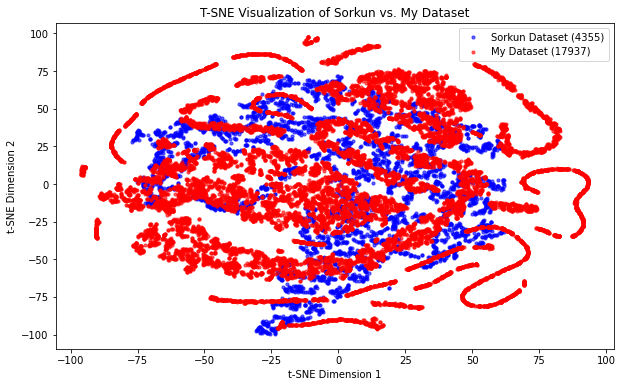

Sorkun Dataset Convex Hull Area: 16485.52
My Dataset Convex Hull Area: 27411.30
 My dataset covers a larger chemical space, indicating better applicability.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot datasets
def plot_tsne(tsne_sorkun, tsne_mydata):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for Sorkun dataset
    plt.scatter(tsne_sorkun[:, 0], tsne_sorkun[:, 1], label="Sorkun Dataset (4355)", alpha=0.6, s=10, c='blue')

    # Scatter plot for ours train  dataset
    plt.scatter(tsne_mydata[:, 0], tsne_mydata[:, 1], label="My Dataset (17937)", alpha=0.6, s=10, c='red')

    plt.legend()
    plt.title("T-SNE Visualization of Sorkun vs. My Dataset")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area


# Compute t-SNE embeddings
tsne_sorkun = compute_tsne(training_set_sorkun)
tsne_mydata = compute_tsne(training_set_self)

# Plot t-SNE visualization
plot_tsne(tsne_sorkun, tsne_mydata)

# Compute convex hull areas
sorkun_area = convex_hull_area(tsne_sorkun)
mydata_area = convex_hull_area(tsne_mydata)

print(f"Sorkun Dataset Convex Hull Area: {sorkun_area:.2f}")
print(f"My Dataset Convex Hull Area: {mydata_area:.2f}")

# Claim better applicability if our dataset has a larger convex hull
if mydata_area > sorkun_area:
    print(" My dataset covers a larger chemical space, indicating better applicability.")
else:
    print("⚠️ Sorkun dataset has better coverage. Consider adding more diverse compounds.")


In [ ]:
### Need to compare how important to increaese the dataset from (A + B) to (A+B+C) and finalily full dataset (A+B+C+D)

In [8]:
### Loading our train data 17937 
import pandas as pd 

train_ABCD=pd.read_csv('../data/final_data/final_unique_train.csv')


In [9]:
train_ABCD.shape

(17937, 8)

In [ ]:
### taking out the And B data 

In [10]:
train_ABCD

,Unnamed: 0,C_ID,Name,InChIKey,SMILES,CAS,LogS,smiles_canon
0,0,A-51,NaN,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,Clc1c2C(=O)c3c(C(=O)c2ccc1)cccc3,NaN,-5.540000,O=C1c2ccccc2C(=O)c2c(Cl)cccc21
1,1,A-53,NaN,BRBKOPJOKNSWSG-UHFFFAOYSA-N,S(=O)(=O)(N=C(N)N)c1ccc(N)cc1,NaN,-1.984970,NC(N)=NS(=O)(=O)c1ccc(N)cc1
2,2,A-55,NaN,BRPOVUNVTUCYNN-UHFFFAOYSA-N,Fc1c(N2C(CC)C(N)C2)cc2n(C3CC3)cc(C(=O)O)c(=O)c2c1,NaN,-3.912000,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1
3,3,A-60,NaN,BWXSXZAIQQSFPW-UHFFFAOYSA-N,O=[N+]([O-])c1cc2C(=O)OC(CC)(CC)c2cc1,NaN,-3.656000,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21
4,4,A-68,NaN,CAQHPYSDQFDJAL-UHFFFAOYSA-N,O=C1C(=NO)c2c(cccc2)C=C1,NaN,-2.937000,O=C1C=Cc2ccccc2C1=NO
...,...,...,...,...,...,...,...,...
17932,19115,B-1403,ISO-OXAZOLE,CTAPFRYPJLPFDF-UHFFFAOYSA-N,C1=CON=C1,000288-14-2,0.383095,c1cnoc1
17933,19116,D-4869,fuberidazole,UYJUZNLFJAWNEZ-UHFFFAOYSA-N,[nH]1c2ccccc2nc1c3occc3,003878-19-1,-3.414016,c1coc(-c2nc3ccccc3[nH]2)c1
17934,19117,B-7032,1H-1.2.4-Triazole,NSPMIYGKQJPBQR-UHFFFAOYSA-N,C1=NC=NN1,000288-88-0,0.897170,c1nc[nH]n1
17935,19118,D-1643,purine,KDCGOANMDULRCW-UHFFFAOYSA-N,[NH]1C=NC2=C1C=NC=N2,000120-73-0,0.619695,c1ncc2[nH]cnc2n1


In [15]:
# Extract subsets based on starting letter
df_A = train_ABCD[train_ABCD['C_ID'].str.startswith('A')]
df_B = train_ABCD[train_ABCD['C_ID'].str.startswith('B')]
df_C = train_ABCD[train_ABCD['C_ID'].str.startswith('C')]
df_D = train_ABCD[train_ABCD['C_ID'].str.startswith('D')]



In [16]:
### Combining Data A and Data B 
df_AB = pd.concat([df_A, df_B], ignore_index=True)


In [19]:
### Taking out the smiles from AB dataset  smiles 
SMILES_AB=df_AB.smiles_canon
### creating  descriptors our data based on the function created 
df_train_AB =utilities.create_feature_multiple(SMILES_AB) 
### creating  descriptors our data based on the function created 
df_train_AB =utilities.create_feature_multiple(SMILES_AB) 
### Now we need to clean the data 
training_set_AB = utilities.clean_data(df_train_AB)

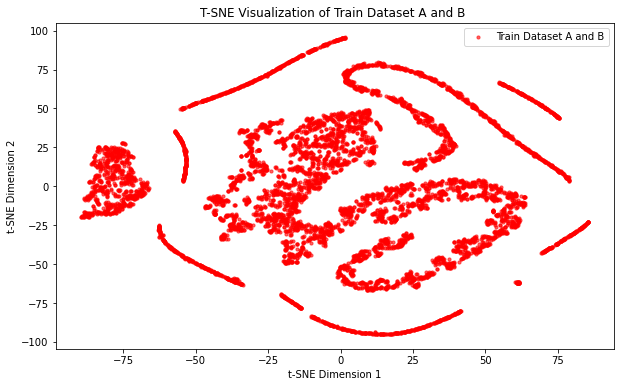

Train Dataset Convex Hull Area: 22107.78


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the dataset
    plt.scatter(tsne_data[:, 0], tsne_data[:, 1], label="Train Dataset A and B", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Train Dataset A and B ")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data = compute_tsne(training_set_AB)

# Plot t-SNE visualization
plot_tsne(tsne_train_data)

# Compute convex hull area
train_data_area = convex_hull_area(tsne_train_data)

print(f"Train Dataset Convex Hull Area: {train_data_area:.2f}")


In [42]:
df_C.shape

(7248, 8)

In [43]:
### Combining Data A B and C 
df_ABC = pd.concat([df_AB, df_C], ignore_index=True)

In [50]:
df_ABC.shape

(15395, 8)

In [45]:
### Taking out the smiles from A B and C dataset  smiles 
SMILES_ABC=df_ABC.smiles_canon
### creating  descriptors our data based on the function created 
df_train_ABC =utilities.create_feature_multiple(SMILES_ABC) 
### Now we need to clean the data 
training_set_ABC = utilities.clean_data(df_train_ABC)

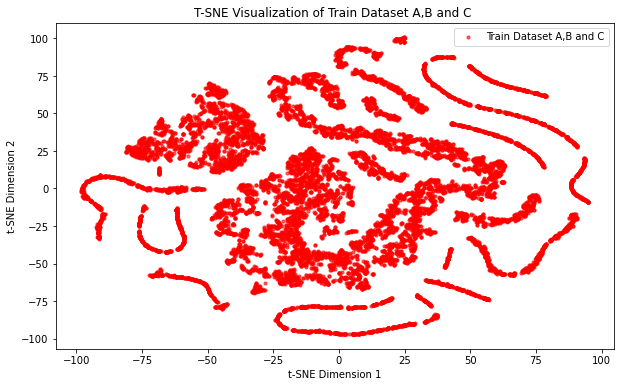

Train Dataset Convex Hull Area for Data A,B and C: 27034.59


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the dataset
    plt.scatter(tsne_data[:, 0], tsne_data[:, 1], label="Train Dataset A,B and C", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Train Dataset A,B and C ")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data = compute_tsne(training_set_ABC)

# Plot t-SNE visualization
plot_tsne(tsne_train_data)

# Compute convex hull area
train_data_area = convex_hull_area(tsne_train_data)

print(f"Train Dataset Convex Hull Area for Data A,B and C: {train_data_area:.2f}")


In [52]:
### Combining Data A B and C 
df_ABCD = pd.concat([df_ABC, df_D], ignore_index=True)

In [53]:
df_ABCD.shape

(17937, 8)

In [58]:
### Taking out the smiles from A B and C dataset  smiles 
SMILES_ABCD=df_ABCD.smiles_canon
### creating  descriptors our data based on the function created 
df_train_ABCD =utilities.create_feature_multiple(SMILES_ABCD) 
### Now we need to clean the data 
training_set_ABCD = utilities.clean_data(df_train_ABCD)

[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:50] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not removing hydrogen atom without neighbors
[23:47:51] WARNING: not r

In [59]:
training_set_ABCD.shape

(17937, 298)

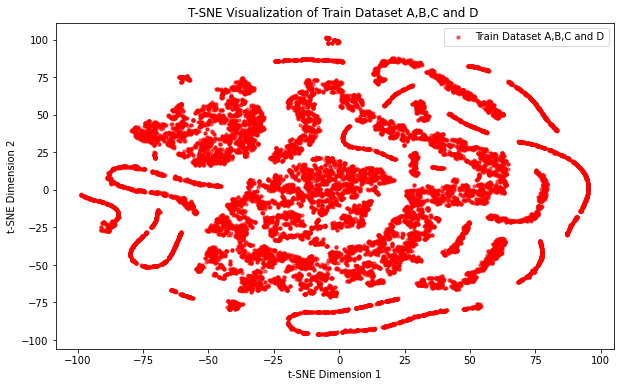

Train Dataset Convex Hull Area for Data A,B,C and D: 27512.14


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the dataset
    plt.scatter(tsne_data[:, 0], tsne_data[:, 1], label="Train Dataset A,B,C and D", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Train Dataset A,B,C and D ")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data = compute_tsne(training_set_ABCD)

# Plot t-SNE visualization
plot_tsne(tsne_train_data)

# Compute convex hull area
train_data_area = convex_hull_area(tsne_train_data)

print(f"Train Dataset Convex Hull Area for Data A,B,C and D: {train_data_area:.2f}")


In [62]:
print(training_set_AB.shape)
print(training_set_ABC.shape)
print(training_set_ABCD.shape)

(8147, 298)
(15395, 298)
(17937, 298)


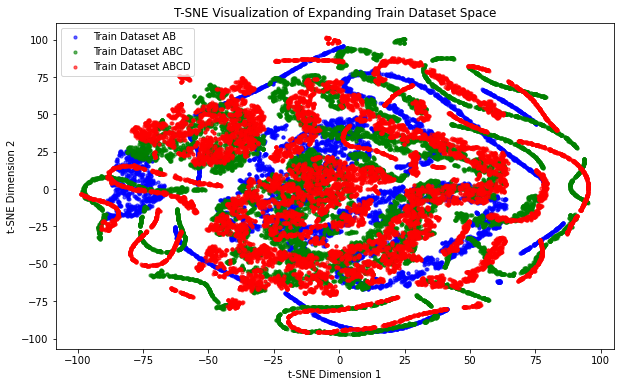

Train Dataset AB Convex Hull Area: 22107.78
Train Dataset ABC Convex Hull Area: 27034.59
Train Dataset ABCD Convex Hull Area: 27512.14


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data_AB, tsne_data_ABC, tsne_data_ABCD):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for different datasets
    plt.scatter(tsne_data_AB[:, 0], tsne_data_AB[:, 1], label="Train Dataset AB", alpha=0.6, s=10, c='blue')
    plt.scatter(tsne_data_ABC[:, 0], tsne_data_ABC[:, 1], label="Train Dataset ABC", alpha=0.6, s=10, c='green')
    plt.scatter(tsne_data_ABCD[:, 0], tsne_data_ABCD[:, 1], label="Train Dataset ABCD", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Expanding Train Dataset Space")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data_AB = compute_tsne(training_set_AB)
tsne_train_data_ABC = compute_tsne(training_set_ABC)
tsne_train_data_ABCD = compute_tsne(training_set_ABCD)

# Plot t-SNE visualization
plot_tsne(tsne_train_data_AB, tsne_train_data_ABC, tsne_train_data_ABCD)

# Compute convex hull areas
train_data_area_AB = convex_hull_area(tsne_train_data_AB)
train_data_area_ABC = convex_hull_area(tsne_train_data_ABC)
train_data_area_ABCD = convex_hull_area(tsne_train_data_ABCD)

print(f"Train Dataset AB Convex Hull Area: {train_data_area_AB:.2f}")
print(f"Train Dataset ABC Convex Hull Area: {train_data_area_ABC:.2f}")
print(f"Train Dataset ABCD Convex Hull Area: {train_data_area_ABCD:.2f}")


In [ ]:
### End here